# Lab: Trees

Lab associated with Module: Trees

***

In [1]:
# The following lines are used to increase the width of cells to utilize more space on the screen 
# (fixed the import: display/HTML moved to IPython.display in newer IPython versions)
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

***

### Section 0: Imports

In [2]:
import numpy as np

Following libraries have to be installed on your computer. Try to install graphviz by using: conda install python-graphviz

I made use of some of the following links to get rid of errors:
    
https://github.com/quadram-institute-bioscience/albatradis/issues/7

https://stackoverflow.com/questions/35064304/runtimeerror-make-sure-the-graphviz-executables-are-on-your-systems-path-aft

https://github.com/xflr6/graphviz/issues/68

https://github.com/RedaOps/ann-visualizer/issues/12


On my mac computer I had to install some packages using brew to get rid of following error: "ExecutableNotFound: failed to execute ['dot', '-Tsvg'], make sure the Graphviz executables are on your systems' PATH"

brew install graphviz

In [3]:
from IPython.display import Image
from graphviz import Digraph

Details of Digraph package: https://h1ros.github.io/posts/introduction-to-graphviz-in-jupyter-notebook/

***

### Section 1: Testing Visualization Package

Let us test this visualization Digraph Pacakge, it is only a tool for displaying tree or graph, this will come handy as it helps to visualize our solution.

In [4]:
dot = Digraph()

dot.node("1")
dot.node("2")
dot.edges(['12'])

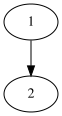

In [5]:
dot

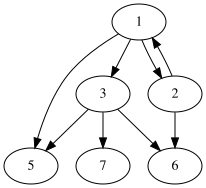

In [6]:
# Create Digraph object
dot = Digraph()

# Add nodes
dot.node('1')
dot.node('3')
dot.node('2')
dot.node('5')
dot.node('6')
dot.node('7')

# Add edges
dot.edges(['12', '13', '35', '15', '21', '37', '36', '26'])

# Visualize the graph
dot

***

### Section 2: Creating a Binary Search Tree

Let us start by creating a BST

We will keep code simple in the sense that we will make a node class, and then build functions outside the class to implement various functionality.

In [7]:
class Node:
    
    def __init__(self, value):

        self.val = value
        self.right = None
        self.left = None
        self.parent = None
        self.balance = 0


def buildBinaryTree(nodes):
    
    if len(nodes) == 0:
        raise ValueError('list is empty')
        
    return binaryTree(nodes, 0, len(nodes) - 1)
        
def binaryTree(nodes, start, end):
    
    if start > end:
        return
    
    middle = (start + end) // 2
    root = Node(nodes[middle])
    root.left = binaryTree(nodes, start, middle - 1)
    root.right = binaryTree(nodes, middle + 1, end)
    
    return root

In [8]:
test1 = [1, 2, 3, 4, 5, 6, 7, 8]
test2 = [-1, 0, 9, 10]

In [9]:
test1_tree = buildBinaryTree(test1)
test2_tree = buildBinaryTree(test2)

We will make the simpler assumption that all the keys are unique when we are inserting

In [10]:
test3 = [0, 1, 2, 3, 3, 3, 5]
test3 = np.unique(test3)

In [11]:
test3_tree = buildBinaryTree(test3)

Okay now that we have build three trees, let us visualize them. For visualization, we will have to write another function.

In [12]:
def visualize_tree(tree):
    
    def add_nodes_edges(tree, dot=None):
        # Create Digraph object
        if dot is None:
            dot = Digraph()
            dot.node(name=str(tree), label=str(tree.val))

        # Add nodes
        if tree.left:
            dot.node(name=str(tree.left) ,label=str(tree.left.val))
            dot.edge(str(tree), str(tree.left))
            dot = add_nodes_edges(tree.left, dot=dot)
            
        if tree.right:
            dot.node(name=str(tree.right) ,label=str(tree.right.val))
            dot.edge(str(tree), str(tree.right))
            dot = add_nodes_edges(tree.right, dot=dot)

        return dot
    
    # Add nodes recursively and create a list of edges
    dot = add_nodes_edges(tree)

    # Visualize the graph
    display(dot)
    
    return dot

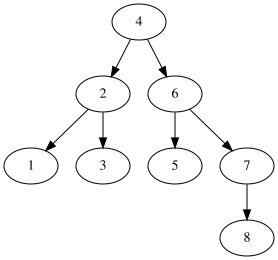

In [13]:
dot = visualize_tree(test1_tree)

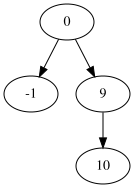

In [14]:
dot = visualize_tree(test2_tree)

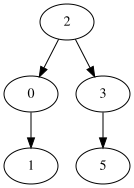

In [15]:
dot = visualize_tree(test3_tree)

***

### Section 3: Implementing Search, Insert and Delete Operations

Let us implement IDS operations on the BST we have built

Search operation should look like:

In [16]:
def search(nodes, val):

    if val == nodes.val:
        return True

    if val < nodes.val:
        
        if nodes.left == None:
            return False

        return search(nodes.left, val)

    elif val >= nodes.val:
        
        if nodes.right == None:
            return False

        return search(nodes.right, val)

In [17]:
search(test3_tree, 3)

True

In [18]:
search(test1_tree, 18)

False

Let us write insert function now:

In [19]:
def insert(nodes, val):

    # Empty Tree
    if nodes == None:
        nodes = Node(val)
        return

    # Value already exist on the node
    if nodes.val == val:
        return

    if val < nodes.val:

        if nodes.left == None: 
            nodes.left = Node(val)
            return
        else:
            insert(nodes.left, val)
            return

    elif val >= nodes.val:
        
        if nodes.right == None:
            nodes.right = Node(val)
            return
        else:
            insert(nodes.right, val)
            return

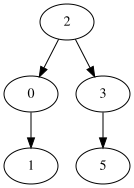

In [20]:
test3 = [0, 1, 2, 3, 3, 3, 5]
test3 = np.unique(test3)

test3_tree = buildBinaryTree(test3)
dot = visualize_tree(test3_tree)

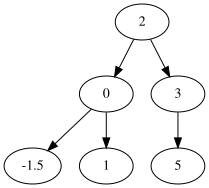

In [21]:
insert(test3_tree, -1.5)
dot = visualize_tree(test3_tree)

Let us write delete opertion. We will write another function minValueNode as well.

In [22]:
def minValueNode(node):
    current = node
 
    # loop down to find the leftmost leaf
    while(current.left is not None):
        current = current.left
 
    return current

def delete(nodes, val):

    if nodes == None:  
        return nodes

    if val < nodes.val:
        
        #if nodes.left:
        nodes.left = delete(nodes.left, val)

    elif val > nodes.val:
        
        #if nodes.right:
        nodes.right = delete(nodes.right, val)

    else:
        
        # Node with only one child or no child
        
        if nodes.left is None:
            temp = nodes.right
            nodes = None
            return temp
        elif nodes.right is None:
            temp = nodes.left
            nodes = None
            return temp
        
        # Nodes with two children: Get the inorder successor
        temp = minValueNode(nodes.right)
        
        nodes.val = temp.val
        
        nodes.right = delete(nodes.right, temp.val)
        
    return nodes

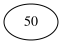

In [23]:
test3_tree = buildBinaryTree([50])
dot = visualize_tree(test3_tree)

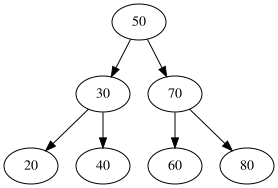

In [24]:
insert(test3_tree, 50)
insert(test3_tree, 30)
insert(test3_tree, 20)
insert(test3_tree, 40)
insert(test3_tree, 70)
insert(test3_tree, 60)
insert(test3_tree, 80)
dot = visualize_tree(test3_tree)

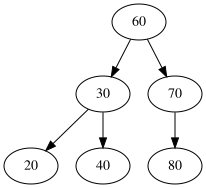

In [25]:
delete(test3_tree, 50)
dot = visualize_tree(test3_tree)

***

### <font color='red'> Section 4: Now that you have a good understanding of BST, write down code for activities in the onTrack Task sheet, in the following section </font>

## Task 1: Lesson Review

This module was a good refresher on binary search trees and then pushed well past what we did in SIT221. The main thing that stuck with me is that a BST only gives you O(log n) search if the tree stays short. The example of inserting 2, 3, 4, 5, 6, 7, 8 in order really drove that home, because you end up with what is basically a linked list wearing a tree costume. Everything after that point in the module is about stopping that from happening.

I found the rotation section the most useful part. Once I understood that a rotation is just a local re-wiring of three pointers that keeps the BST ordering intact, AVL trees stopped feeling like magic. The four cases (right, left, left-right, right-left) made a lot more sense after I drew the P, Q and C placements out on paper a few times. The RB tree section was harder. I can follow the five rules and I get the idea that the colours are just a proxy for balance, but the insert fixup cases took me a couple of passes through the CLRS pseudocode and the video before they clicked. Deletion fixup I understand at the "I can trace it" level rather than the "I could rederive it" level, which I am okay with for now since the module notes say we are not responsible for the internal mechanism.

I will use the information in this module directly at work. I build search indexers as part of my job, and understanding why databases use B+ trees rather than plain BSTs (bigger fan-out per disk page, all data in linked leaves, sequential range scans) explains a lot of behaviour I have seen in PostgreSQL query plans. The range query task made this concrete, since walking the leaf chain is exactly why BETWEEN queries on an indexed column are fast.

A few reflection points using the template:

1. I will use the balance tracking and rotation code from this module as the base for my D/HD work, and the B+ tree understanding to reason about database index performance at work.
2. The explanation in the AVL section could be improved by adding a worked example for each of the four rotation cases, not just the left-right one. The notes say "we leave it as an exercise", which is fair, but one worked example of a right-left case would help check your own answers against something.
3. We can better explain RB tree insertion by pairing each fixup case with a tiny 4 or 5 node figure showing before and after, rather than only the full CLRS pseudocode.
4. There is a good visual resource for checking B tree and B+ tree answers: the University of San Francisco data structure visualisations by David Galles. I used it to sanity check my Task 6 intermediate steps.
5. I am keen to discuss with my tutor whether the balance field should be maintained incrementally during insert and delete (like I did) or whether recomputing it lazily inside is_balanced would be acceptable, and what the trade-off is in practice.
6. I would like to know more about how RB trees behave under heavy concurrent writes, because I have read that some databases prefer them for in-memory structures while B+ trees are used on disk, and I want to understand why the split is at the memory/disk boundary.

**Code reflection.** I ran the provided lab code and my Section 4 code with the following test cases: a balanced 7 node tree (is_balanced returns True), the sorted insert sequence 2 to 8 (returns False), deleting an entire left subtree to force imbalance, rotations at both the root and internal nodes, the full RB insert/delete sequence from the task sheet with a property checker running after every single operation, and B+/B tree insertion of all 16 strings with the leaf chain checked against the sorted input. I found that the provided insert function never sets parent pointers and never touches the balance field even though the Node class has one, and the provided delete does not maintain them either. I modified the code so insert and delete return the subtree root and update height and balance on the way back up the recursion, which means the balance field is always correct without any extra traversal. I also simplified the right-branch condition in search from val >= node.val to a plain else, since the equal case is already handled before it, and fixed the deprecated `from IPython.core.display import display, HTML` import in the first cell, which errors on newer IPython versions (display now lives in `IPython.display`). You can check the sections below where I ran everything and got the expected output, including figures generated after every RB tree operation and after every third B+ tree insertion.

## Task 2: Balance Tracking in a BST

The Node class already had a `balance` field but nothing in the lab code ever updated it. My approach:

* each node also stores its `height` (a leaf has height 0, an empty subtree counts as -1)
* `insert` and `delete` are written to return the subtree root, so on the way back up the recursion every node on the path recomputes its height and balance in O(1)
* `balance = height(left) - height(right)`, and `is_balanced(tree)` just checks every node has balance in {-1, 0, 1}

This costs nothing extra in big-O terms: insert and delete already walk one root-to-node path, and we only update the nodes on that same path.

Note: Section 4 is self contained. I redefine Node, insert and delete here so the balance bookkeeping is built in.

In [26]:
class Node:

    def __init__(self, value):
        self.val = value
        self.right = None
        self.left = None
        self.parent = None
        self.balance = 0
        self.height = 0   # height of the subtree rooted at this node


def node_height(node):
    # height of an empty subtree is -1, so a leaf works out to 0
    if node is None:
        return -1
    return node.height


def update_node(node):
    # recompute this node's height and balance from its children
    node.height = 1 + max(node_height(node.left), node_height(node.right))
    node.balance = node_height(node.left) - node_height(node.right)


def insert(node, val):
    if node is None:
        return Node(val)

    if val == node.val:
        return node   # keys are unique, ignore duplicates

    if val < node.val:
        node.left = insert(node.left, val)
        node.left.parent = node
    else:
        node.right = insert(node.right, val)
        node.right.parent = node

    update_node(node)   # fix height + balance on the way back up
    return node


def minValueNode(node):
    current = node
    while current.left is not None:
        current = current.left
    return current


def delete(node, val):
    if node is None:
        return None

    if val < node.val:
        node.left = delete(node.left, val)
        if node.left:
            node.left.parent = node
    elif val > node.val:
        node.right = delete(node.right, val)
        if node.right:
            node.right.parent = node
    else:
        # zero or one child: just splice it out
        if node.left is None:
            temp = node.right
            if temp:
                temp.parent = node.parent
            return temp
        elif node.right is None:
            temp = node.left
            if temp:
                temp.parent = node.parent
            return temp
        # two children: copy in-order successor value, then delete it below
        temp = minValueNode(node.right)
        node.val = temp.val
        node.right = delete(node.right, temp.val)
        if node.right:
            node.right.parent = node

    update_node(node)
    return node


def buildBinaryTree(nodes):
    if len(nodes) == 0:
        raise ValueError('list is empty')
    root = None
    for v in nodes:
        root = insert(root, v)
    return root


def is_balanced(tree):
    if tree is None:
        return True
    if abs(tree.balance) > 1:
        return False
    return is_balanced(tree.left) and is_balanced(tree.right)

In [27]:
def visualize_tree_balance(tree):
    # same idea as the lab's visualize_tree, but each node also shows its balance value
    def add_nodes_edges(t, dot=None):
        if dot is None:
            dot = Digraph()
            dot.node(name=str(t), label=f"{t.val}\nb={t.balance}")
        if t.left:
            dot.node(name=str(t.left), label=f"{t.left.val}\nb={t.left.balance}")
            dot.edge(str(t), str(t.left))
            dot = add_nodes_edges(t.left, dot)
        if t.right:
            dot.node(name=str(t.right), label=f"{t.right.val}\nb={t.right.balance}")
            dot.edge(str(t), str(t.right))
            dot = add_nodes_edges(t.right, dot)
        return dot
    return add_nodes_edges(tree)

is_balanced: True


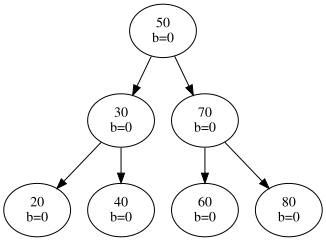

In [28]:
# Test 1: a nicely balanced tree
balanced_tree = buildBinaryTree([50, 30, 20, 40, 70, 60, 80])
print("is_balanced:", is_balanced(balanced_tree))
visualize_tree_balance(balanced_tree)

is_balanced: False


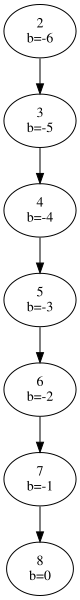

In [29]:
# Test 2: the pathological case from the module notes (sorted inserts)
skewed_tree = buildBinaryTree([2, 3, 4, 5, 6, 7, 8])
print("is_balanced:", is_balanced(skewed_tree))
visualize_tree_balance(skewed_tree)

is_balanced after deleting 20, 40, 30: False


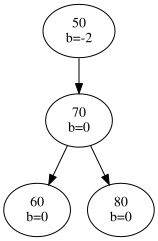

In [30]:
# Test 3: deletions keep the balance field correct too.
# Delete the whole left side of the balanced tree and watch it tip over.
t = buildBinaryTree([50, 30, 20, 40, 70, 60, 80])
t = delete(t, 20)
t = delete(t, 40)
t = delete(t, 30)
print("is_balanced after deleting 20, 40, 30:", is_balanced(t))
visualize_tree_balance(t)

## Task 3: First Common Ancestor in a BST

As the task asks, I first search for both nodes to make sure they actually exist, and only then find the ancestor. The ancestor search uses the BST ordering property: starting at the root, if both values are smaller than the current node the ancestor must be in the left subtree, if both are larger it must be in the right subtree, and the first node where the two paths split (or where we land on one of the values itself) is the lowest common ancestor.

Pseudocode:

```
FIRST-COMMON-ANCESTOR(T, v1, v2):
    if SEARCH(T, v1) is missing or SEARCH(T, v2) is missing:
        return NIL
    current = T.root
    while current is not NIL:
        if v1 < current.val and v2 < current.val:
            current = current.left
        else if v1 > current.val and v2 > current.val:
            current = current.right
        else:
            return current      # the paths split here
```

The two initial searches cost O(h) each and the ancestor walk is another O(h), so the whole thing is O(h), which is O(log n) on a balanced tree.

In [31]:
def search_node(node, val):
    # like the lab's search, but returns the actual node instead of True/False
    if node is None:
        return None
    if val == node.val:
        return node
    if val < node.val:
        return search_node(node.left, val)
    return search_node(node.right, val)


def first_common_ancestor(tree, val1, val2):
    # step 1: search for both nodes first, as required by the task
    n1 = search_node(tree, val1)
    n2 = search_node(tree, val2)
    if n1 is None or n2 is None:
        return None

    # step 2: walk down from the root until the two paths split
    current = tree
    while current is not None:
        if val1 < current.val and val2 < current.val:
            current = current.left
        elif val1 > current.val and val2 > current.val:
            current = current.right
        else:
            return current
    return None

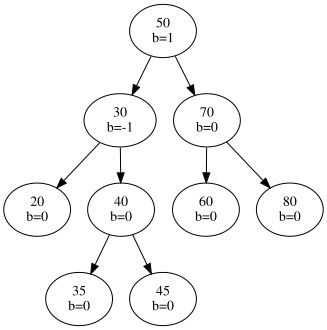

In [32]:
lca_tree = buildBinaryTree([50, 30, 20, 40, 70, 60, 80, 35, 45])
visualize_tree_balance(lca_tree)

In [33]:
test_pairs = [(20, 40), (35, 45), (20, 80), (60, 80), (30, 40), (40, 45)]
for a, b in test_pairs:
    lca = first_common_ancestor(lca_tree, a, b)
    print(f"first_common_ancestor({a}, {b}) = {lca.val}")

# a value that is not in the tree should give None
print("first_common_ancestor(20, 999) =", first_common_ancestor(lca_tree, 20, 999))

first_common_ancestor(20, 40) = 30
first_common_ancestor(35, 45) = 40
first_common_ancestor(20, 80) = 50
first_common_ancestor(60, 80) = 70
first_common_ancestor(30, 40) = 30
first_common_ancestor(40, 45) = 40
first_common_ancestor(20, 999) = None


## Task 4: Rotations in a BST

Following the seminar naming: P is the node the rotation is applied to, Q is the relevant child of P, and C is the relevant child of Q. The subtrees hanging off them (T1 to T4) just get re-attached, and the BST ordering survives because a rotation only swaps a parent-child relationship along one edge.

Pseudocode for a right rotation on P (left rotation is the mirror image):

```
RIGHT-ROTATE(T, P):
    Q = P.left
    P.left = Q.right          # T2 moves across to P
    Q.right = P               # Q becomes the parent of P
    hook Q into the place P used to occupy
    return updated tree
```

The double rotations are just two singles in a row:

* left-right on P = left rotation on Q (P's left child), then right rotation on P
* right-left on P = right rotation on Q (P's right child), then left rotation on P

Each function takes the tree and the node to rotate at, and returns the updated tree, as the task asks. Because a rotation can change the root, I find P's parent by walking down from the root, and after re-wiring I refresh the heights and balance values of the affected nodes on the way back up.

In [34]:
def find_parent(root, node):
    # walk down from the root to find the parent of node (None if node is the root)
    if root is node:
        return None
    current = root
    while current is not None:
        if node.val < current.val:
            if current.left is node:
                return current
            current = current.left
        else:
            if current.right is node:
                return current
            current = current.right
    return None


def replace_child(root, parent, old_child, new_child):
    # hook new_child into the spot old_child used to occupy,
    # returns the (possibly new) root of the tree
    new_child.parent = parent
    if parent is None:
        return new_child          # old_child was the root
    if parent.left is old_child:
        parent.left = new_child
    else:
        parent.right = new_child
    return root


def refresh_upwards(node):
    # after a rotation, heights change for the rotated nodes and everything above
    while node is not None:
        update_node(node)
        node = node.parent


def rightRotate(root, P):
    Q = P.left
    if Q is None:
        return root               # cannot right-rotate without a left child

    parent = find_parent(root, P)

    # Q's right subtree (T2) becomes P's left subtree
    P.left = Q.right
    if Q.right:
        Q.right.parent = P

    # Q takes P's place, P becomes Q's right child
    Q.right = P
    root = replace_child(root, parent, P, Q)
    P.parent = Q

    update_node(P)
    refresh_upwards(Q)
    return root


def leftRotate(root, P):
    Q = P.right
    if Q is None:
        return root               # cannot left-rotate without a right child

    parent = find_parent(root, P)

    # Q's left subtree (T2) becomes P's right subtree
    P.right = Q.left
    if Q.left:
        Q.left.parent = P

    # Q takes P's place, P becomes Q's left child
    Q.left = P
    root = replace_child(root, parent, P, Q)
    P.parent = Q

    update_node(P)
    refresh_upwards(Q)
    return root


def leftRightRotate(root, P):
    # Case 3: Q is P's left child, C is Q's right child
    Q = P.left
    if Q is None or Q.right is None:
        return root
    root = leftRotate(root, Q)
    root = rightRotate(root, P)
    return root


def rightLeftRotate(root, P):
    # Case 4: Q is P's right child, C is Q's left child
    Q = P.right
    if Q is None or Q.left is None:
        return root
    root = rightRotate(root, Q)
    root = leftRotate(root, P)
    return root

before right rotation on 50:


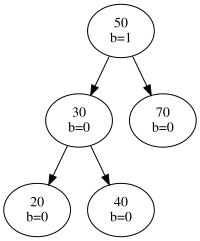

after (30 is the new root, 40 crossed over to become 50's left child):


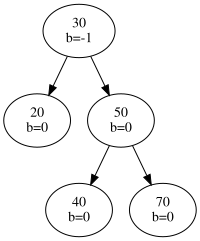

In [35]:
# Scenario 1: right rotation at the root
t = buildBinaryTree([50, 30, 20, 40, 70])
print("before right rotation on 50:")
display(visualize_tree_balance(t))

t = rightRotate(t, t)
print("after (30 is the new root, 40 crossed over to become 50's left child):")
visualize_tree_balance(t)

before left rotation on 30:


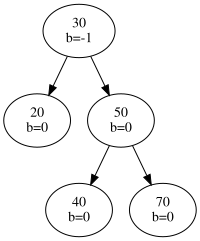

after (50 is the new root, 40 crossed over):


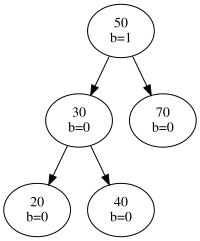

In [36]:
# Scenario 2: left rotation at the root
t = buildBinaryTree([30, 20, 50, 40, 70])
print("before left rotation on 30:")
display(visualize_tree_balance(t))

t = leftRotate(t, t)
print("after (50 is the new root, 40 crossed over):")
visualize_tree_balance(t)

before right rotation on internal node 50:


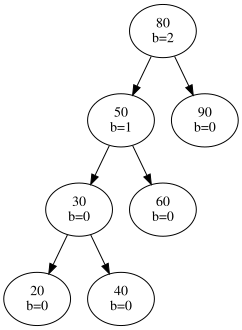

after (30 took 50's place under 80, and the root is unchanged):


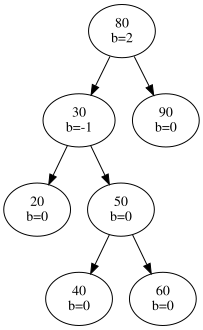

In [37]:
# Scenario 3: rotation at an internal node (not the root)
t = buildBinaryTree([80, 50, 90, 30, 60, 20, 40])
print("before right rotation on internal node 50:")
display(visualize_tree_balance(t))

node50 = search_node(t, 50)
t = rightRotate(t, node50)
print("after (30 took 50's place under 80, and the root is unchanged):")
visualize_tree_balance(t)

before, is_balanced: False


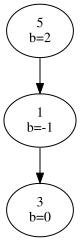

after left-right rotation, is_balanced: True


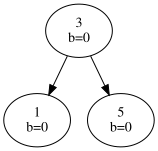

In [38]:
# Scenario 4: left-right double rotation, the classic AVL zig-zag
t = buildBinaryTree([5, 1, 3])
print("before, is_balanced:", is_balanced(t))
display(visualize_tree_balance(t))

t = leftRightRotate(t, t)
print("after left-right rotation, is_balanced:", is_balanced(t))
visualize_tree_balance(t)

before, is_balanced: False


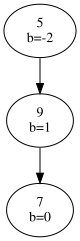

after right-left rotation, is_balanced: True


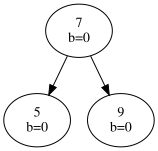

In [39]:
# Scenario 5: right-left double rotation, the mirror zig-zag
t = buildBinaryTree([5, 9, 7])
print("before, is_balanced:", is_balanced(t))
display(visualize_tree_balance(t))

t = rightLeftRotate(t, t)
print("after right-left rotation, is_balanced:", is_balanced(t))
visualize_tree_balance(t)

before left-right rotation on 50:


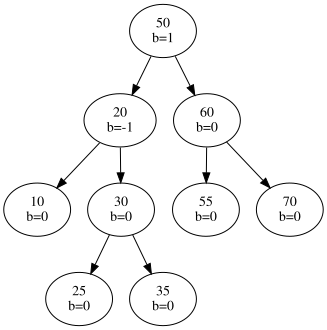

after (30 is the new root, 25 went under 20 and 35 went under 50):


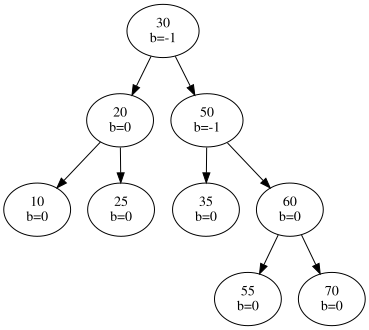

In [40]:
# Scenario 6: left-right rotation where all four subtrees T1-T4 are populated,
# to show the subtree re-attachment works and not just the trivial 3 node case
t = buildBinaryTree([50, 20, 60, 10, 30, 25, 35, 55, 70])
print("before left-right rotation on 50:")
display(visualize_tree_balance(t))

node50 = search_node(t, 50)
t = leftRightRotate(t, node50)
print("after (30 is the new root, 25 went under 20 and 35 went under 50):")
visualize_tree_balance(t)

## Task 5: Red-Black Tree Insertion and Deletion

I chose the code visualisation option for the figures. I implemented the RB tree following the CLRS pseudocode (insert with RB-INSERT-FIXUP, delete with RB-TRANSPLANT and RB-DELETE-FIXUP, and a NIL sentinel node). A figure is generated after every single insertion and deletion, and each figure is labelled with the operation that produced it.

To be sure every intermediate tree is legitimate, I also wrote a checker that verifies all the RB properties from the module notes after every operation: the root is black, no red node has a red child, and every path from any node down to the NIL leaves has the same number of black nodes. If any property ever broke, the checker would throw an error and the notebook would stop.

In [41]:
RED = "RED"
BLACK = "BLACK"

class RBNode:
    def __init__(self, val, color=RED):
        self.val = val
        self.color = color
        self.left = None
        self.right = None
        self.parent = None


class RBTree:
    def __init__(self):
        self.NIL = RBNode(None, BLACK)   # single shared sentinel, counts as black
        self.root = self.NIL

    # ---- rotations, same idea as Task 4 but using parent pointers ----
    def left_rotate(self, x):
        y = x.right
        x.right = y.left
        if y.left is not self.NIL:
            y.left.parent = x
        y.parent = x.parent
        if x.parent is self.NIL:
            self.root = y
        elif x is x.parent.left:
            x.parent.left = y
        else:
            x.parent.right = y
        y.left = x
        x.parent = y

    def right_rotate(self, x):
        y = x.left
        x.left = y.right
        if y.right is not self.NIL:
            y.right.parent = x
        y.parent = x.parent
        if x.parent is self.NIL:
            self.root = y
        elif x is x.parent.right:
            x.parent.right = y
        else:
            x.parent.left = y
        y.right = x
        x.parent = y

    # ---- insertion (CLRS RB-INSERT) ----
    def insert(self, val):
        z = RBNode(val)
        z.left = self.NIL
        z.right = self.NIL
        y = self.NIL
        x = self.root
        while x is not self.NIL:
            y = x
            x = x.left if z.val < x.val else x.right
        z.parent = y
        if y is self.NIL:
            self.root = z
        elif z.val < y.val:
            y.left = z
        else:
            y.right = z
        z.color = RED                 # new nodes always start red
        self.insert_fixup(z)

    def insert_fixup(self, z):
        while z.parent.color == RED:
            if z.parent is z.parent.parent.left:
                y = z.parent.parent.right         # the uncle
                if y.color == RED:
                    # case 1: red uncle, recolour and move the problem up
                    z.parent.color = BLACK
                    y.color = BLACK
                    z.parent.parent.color = RED
                    z = z.parent.parent
                else:
                    if z is z.parent.right:
                        # case 2: zig-zag, rotate to turn it into case 3
                        z = z.parent
                        self.left_rotate(z)
                    # case 3: recolour and rotate the grandparent
                    z.parent.color = BLACK
                    z.parent.parent.color = RED
                    self.right_rotate(z.parent.parent)
            else:
                # mirror image of the above
                y = z.parent.parent.left
                if y.color == RED:
                    z.parent.color = BLACK
                    y.color = BLACK
                    z.parent.parent.color = RED
                    z = z.parent.parent
                else:
                    if z is z.parent.left:
                        z = z.parent
                        self.right_rotate(z)
                    z.parent.color = BLACK
                    z.parent.parent.color = RED
                    self.left_rotate(z.parent.parent)
        self.root.color = BLACK

    # ---- deletion (CLRS RB-DELETE) ----
    def transplant(self, u, v):
        if u.parent is self.NIL:
            self.root = v
        elif u is u.parent.left:
            u.parent.left = v
        else:
            u.parent.right = v
        v.parent = u.parent

    def minimum(self, x):
        while x.left is not self.NIL:
            x = x.left
        return x

    def search(self, val):
        x = self.root
        while x is not self.NIL and x.val != val:
            x = x.left if val < x.val else x.right
        return x

    def delete(self, val):
        z = self.search(val)
        if z is self.NIL:
            return False
        y = z
        y_original_color = y.color
        if z.left is self.NIL:
            x = z.right
            self.transplant(z, z.right)
        elif z.right is self.NIL:
            x = z.left
            self.transplant(z, z.left)
        else:
            y = self.minimum(z.right)   # in-order successor
            y_original_color = y.color
            x = y.right
            if y.parent is z:
                x.parent = y
            else:
                self.transplant(y, y.right)
                y.right = z.right
                y.right.parent = y
            self.transplant(z, y)
            y.left = z.left
            y.left.parent = y
            y.color = z.color
        if y_original_color == BLACK:
            # removing a black node may break the black depth property
            self.delete_fixup(x)
        return True

    def delete_fixup(self, x):
        while x is not self.root and x.color == BLACK:
            if x is x.parent.left:
                w = x.parent.right              # the sibling
                if w.color == RED:
                    # case 1: red sibling, rotate so the sibling is black
                    w.color = BLACK
                    x.parent.color = RED
                    self.left_rotate(x.parent)
                    w = x.parent.right
                if w.left.color == BLACK and w.right.color == BLACK:
                    # case 2: sibling has two black children, recolour and move up
                    w.color = RED
                    x = x.parent
                else:
                    if w.right.color == BLACK:
                        # case 3: rotate to turn it into case 4
                        w.left.color = BLACK
                        w.color = RED
                        self.right_rotate(w)
                        w = x.parent.right
                    # case 4: final rotation fixes the black deficit
                    w.color = x.parent.color
                    x.parent.color = BLACK
                    w.right.color = BLACK
                    self.left_rotate(x.parent)
                    x = self.root
            else:
                # mirror image of the above
                w = x.parent.left
                if w.color == RED:
                    w.color = BLACK
                    x.parent.color = RED
                    self.right_rotate(x.parent)
                    w = x.parent.left
                if w.right.color == BLACK and w.left.color == BLACK:
                    w.color = RED
                    x = x.parent
                else:
                    if w.left.color == BLACK:
                        w.right.color = BLACK
                        w.color = RED
                        self.left_rotate(w)
                        w = x.parent.left
                    w.color = x.parent.color
                    x.parent.color = BLACK
                    w.left.color = BLACK
                    self.right_rotate(x.parent)
                    x = self.root
        x.color = BLACK

In [42]:
def visualize_rb(tree):
    # red nodes drawn red, black nodes drawn black with white text
    dot = Digraph()
    dot.attr('node', style='filled', fontcolor='white', shape='circle')

    def walk(node):
        colour = 'red3' if node.color == RED else 'black'
        dot.node(name=str(id(node)), label=str(node.val), fillcolor=colour)
        for child in (node.left, node.right):
            if child is not tree.NIL:
                walk(child)
                dot.edge(str(id(node)), str(id(child)))
    if tree.root is not tree.NIL:
        walk(tree.root)
    return dot


def validate_rb(tree):
    # checks the RB rules from the module notes, throws if any of them break
    assert tree.root.color == BLACK, "root must be black"
    def walk(node):
        if node is tree.NIL:
            return 1                     # NIL children count as black
        if node.color == RED:
            assert node.left.color == BLACK and node.right.color == BLACK, \
                f"red node {node.val} has a red child"
        if node.left is not tree.NIL:
            assert node.left.val < node.val, "BST order broken"
        if node.right is not tree.NIL:
            assert node.right.val > node.val, "BST order broken"
        bl = walk(node.left)
        br = walk(node.right)
        assert bl == br, f"black depths differ under node {node.val}"
        return bl + (1 if node.color == BLACK else 0)
    walk(tree.root)
    return True

After insert(18)  [all RB properties verified]


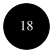

After insert(2)  [all RB properties verified]


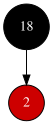

After insert(1)  [all RB properties verified]


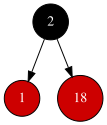

After insert(12)  [all RB properties verified]


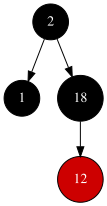

After insert(15)  [all RB properties verified]


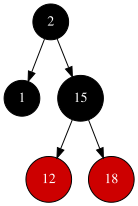

After insert(9)  [all RB properties verified]


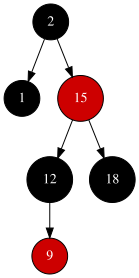

After insert(10)  [all RB properties verified]


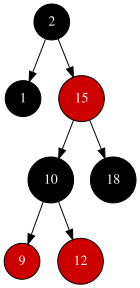

After insert(13)  [all RB properties verified]


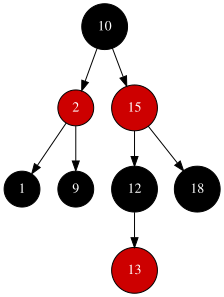

After insert(6)  [all RB properties verified]


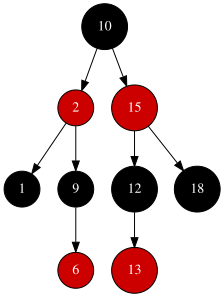

After insert(7)  [all RB properties verified]


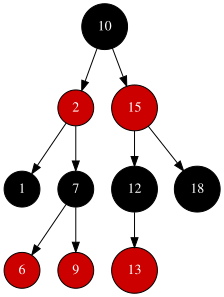

After insert(4)  [all RB properties verified]


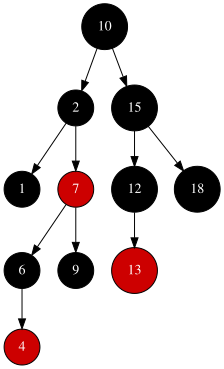

After insert(29)  [all RB properties verified]


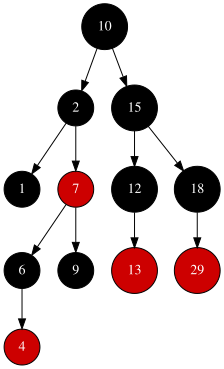

In [43]:
# Insertions in the exact order from the task sheet, one figure per insertion
rb = RBTree()
for v in [18, 2, 1, 12, 15, 9, 10, 13, 6, 7, 4, 29]:
    rb.insert(v)
    validate_rb(rb)
    print(f"After insert({v})  [all RB properties verified]")
    display(visualize_rb(rb))

After delete(2)  [all RB properties verified]


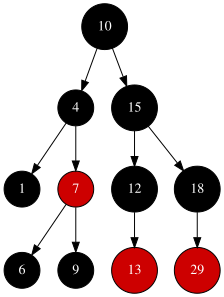

After delete(29)  [all RB properties verified]


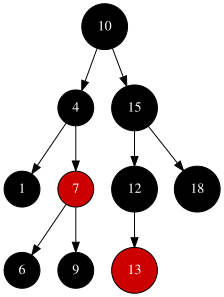

After delete(18)  [all RB properties verified]


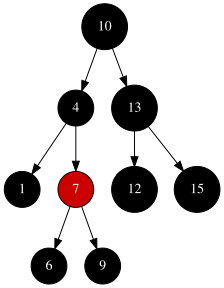

In [44]:
# Deletions in the exact order from the task sheet, one figure per deletion
for v in [2, 29, 18]:
    rb.delete(v)
    validate_rb(rb)
    print(f"After delete({v})  [all RB properties verified]")
    display(visualize_rb(rb))

## Task 6: B+ Tree Insertion (Order m = 3)

Order 3 means every node holds at most 2 keys (3 children for internal nodes). Splitting rules used:

* **Leaf split**: when a leaf overflows to 3 keys, it splits into a left leaf with 1 key and a right leaf with 2 keys, and the first key of the new right leaf is **copied** up into the parent. The leaf keeps a `next` pointer to the new right leaf so the leaf chain stays connected.
* **Internal split**: when an internal node overflows to 3 keys, the middle key **moves** up into the parent (it is not copied, since internal keys are only signposts in a B+ tree).

In the figures below, solid arrows are parent-child pointers and the dashed arrows along the bottom row are the leaf chain pointers. As required, a figure is shown after every third insertion (and after the final 16th insertion).

In [45]:
class BPlusNode:
    def __init__(self, leaf=True):
        self.keys = []
        self.children = []      # internal nodes only
        self.leaf = leaf
        self.next = None        # leaf chain pointer
        self.parent = None


class BPlusTree:
    def __init__(self, order=3):
        self.order = order      # max children; max keys per node = order - 1
        self.root = BPlusNode(leaf=True)

    def find_leaf(self, key):
        node = self.root
        while not node.leaf:
            i = 0
            while i < len(node.keys) and key >= node.keys[i]:
                i += 1
            node = node.children[i]
        return node

    def insert(self, key):
        leaf = self.find_leaf(key)
        if key in leaf.keys:
            return
        leaf.keys.append(key)
        leaf.keys.sort()
        if len(leaf.keys) > self.order - 1:
            self.split_leaf(leaf)

    def split_leaf(self, leaf):
        mid = len(leaf.keys) // 2          # 3 keys -> left keeps 1, right takes 2
        new_leaf = BPlusNode(leaf=True)
        new_leaf.keys = leaf.keys[mid:]
        leaf.keys = leaf.keys[:mid]

        # keep the leaf chain connected
        new_leaf.next = leaf.next
        leaf.next = new_leaf

        # the first key of the new right leaf gets COPIED up
        self.insert_in_parent(leaf, new_leaf.keys[0], new_leaf)

    def split_internal(self, node):
        mid = len(node.keys) // 2
        push_key = node.keys[mid]          # middle key MOVES up
        new_node = BPlusNode(leaf=False)
        new_node.keys = node.keys[mid + 1:]
        new_node.children = node.children[mid + 1:]
        for c in new_node.children:
            c.parent = new_node
        node.keys = node.keys[:mid]
        node.children = node.children[:mid + 1]
        self.insert_in_parent(node, push_key, new_node)

    def insert_in_parent(self, left, key, right):
        if left is self.root:
            new_root = BPlusNode(leaf=False)
            new_root.keys = [key]
            new_root.children = [left, right]
            left.parent = new_root
            right.parent = new_root
            self.root = new_root
            return
        parent = left.parent
        idx = parent.children.index(left)
        parent.keys.insert(idx, key)
        parent.children.insert(idx + 1, right)
        right.parent = parent
        if len(parent.keys) > self.order - 1:
            self.split_internal(parent)

    def range_query(self, low, high):
        # Task 9: walk down once, then scan right along the leaf chain
        result = []
        leaf = self.find_leaf(low)
        while leaf is not None:
            for k in leaf.keys:
                if low <= k <= high:
                    result.append(k)
                elif k > high:
                    return result       # keys are sorted, safe to stop early
            leaf = leaf.next
        return result

    def internal_node_count(self):
        count = 0
        stack = [self.root]
        while stack:
            n = stack.pop()
            if not n.leaf:
                count += 1
                stack.extend(n.children)
        return count

    def leaf_count(self):
        count = 0
        stack = [self.root]
        while stack:
            n = stack.pop()
            if n.leaf:
                count += 1
            else:
                stack.extend(n.children)
        return count

    def leaf_chain(self):
        node = self.root
        while not node.leaf:
            node = node.children[0]
        out = []
        while node:
            out.append(node.keys)
            node = node.next
        return out

In [46]:
def visualize_bplus(tree):
    dot = Digraph()
    dot.attr('node', shape='box')

    def walk(node):
        label = " | ".join(str(k) for k in node.keys)
        if node.leaf:
            dot.node(name=str(id(node)), label=label, style='filled', fillcolor='lightyellow')
        else:
            dot.node(name=str(id(node)), label=label)
            for child in node.children:
                walk(child)
                dot.edge(str(id(node)), str(id(child)))
    walk(tree.root)

    # dashed arrows for the leaf chain, kept on the same rank
    node = tree.root
    while not node.leaf:
        node = node.children[0]
    with dot.subgraph() as s:
        s.attr(rank='same')
        n = node
        while n:
            s.node(str(id(n)))
            n = n.next
    while node.next:
        dot.edge(str(id(node)), str(id(node.next)), style='dashed', constraint='false')
        node = node.next
    return dot

B+ Tree after 3 insertions (just inserted 'bat')


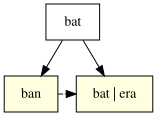

B+ Tree after 6 insertions (just inserted 'log')


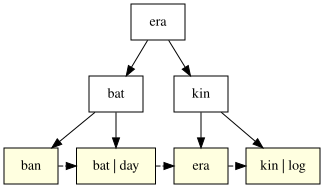

B+ Tree after 9 insertions (just inserted 'won')


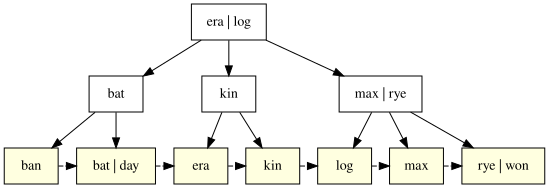

B+ Tree after 12 insertions (just inserted 'bug')


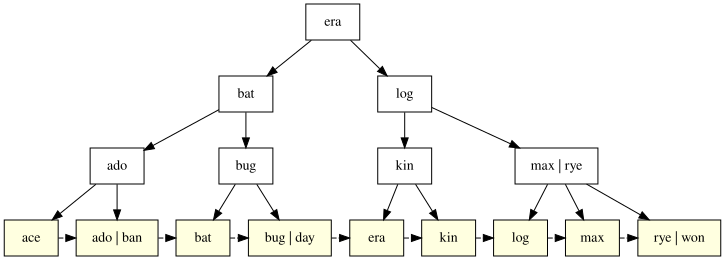

B+ Tree after 15 insertions (just inserted 'let')


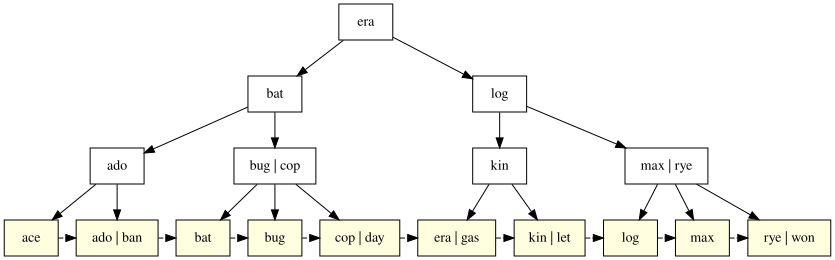

B+ Tree after 16 insertions (just inserted 'fax')


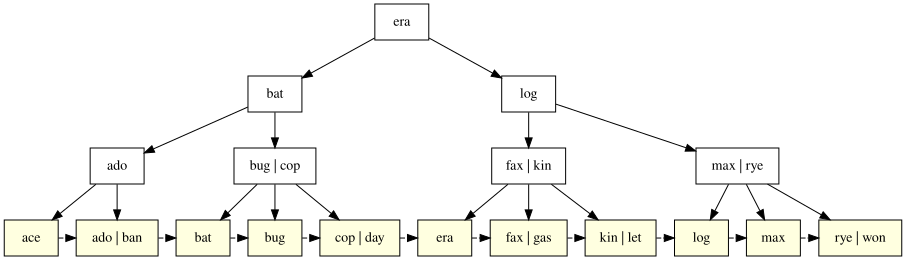

In [47]:
strings = ["era", "ban", "bat", "kin", "day", "log", "rye", "max",
           "won", "ace", "ado", "bug", "cop", "gas", "let", "fax"]

bplus = BPlusTree(order=3)
for i, s in enumerate(strings, 1):
    bplus.insert(s)
    if i % 3 == 0 or i == len(strings):
        print(f"B+ Tree after {i} insertions (just inserted '{s}')")
        display(visualize_bplus(bplus))

In [48]:
# sanity check: walking the leaf chain must give every key in sorted order
chain = [k for leaf in bplus.leaf_chain() for k in leaf]
print("leaf chain:", " -> ".join("[" + " ".join(l) + "]" for l in bplus.leaf_chain()))
print("chain matches sorted input:", chain == sorted(strings))

leaf chain: [ace] -> [ado ban] -> [bat] -> [bug] -> [cop day] -> [era] -> [fax gas] -> [kin let] -> [log] -> [max] -> [rye won]
chain matches sorted input: True


## Task 7: B Tree Insertion (Order m = 3)

Same 16 strings, but this time a plain B tree (a 2-3 tree). The key difference from Task 6: when a node overflows, the middle key **moves** up into the parent and is gone from the child. Keys live everywhere in the tree, not just in the leaves, and there is no leaf chain. Only the final tree is shown, as the task allows.

In [49]:
class BNode:
    def __init__(self, leaf=True):
        self.keys = []
        self.children = []
        self.leaf = leaf


class BTree:
    def __init__(self, order=3):
        self.order = order
        self.root = BNode(leaf=True)

    def insert(self, key):
        self._insert(self.root, key)
        if len(self.root.keys) > self.order - 1:
            # root overflowed: split it and grow the tree one level
            old_root = self.root
            self.root = BNode(leaf=False)
            self._split_child(self.root, 0, old_root, is_root=True)

    def _insert(self, node, key):
        if key in node.keys:
            return
        if node.leaf:
            node.keys.append(key)
            node.keys.sort()
        else:
            i = 0
            while i < len(node.keys) and key > node.keys[i]:
                i += 1
            child = node.children[i]
            self._insert(child, key)
            if len(child.keys) > self.order - 1:
                self._split_child(node, i, child)

    def _split_child(self, parent, idx, child, is_root=False):
        mid = len(child.keys) // 2
        push_key = child.keys[mid]           # middle key MOVES up
        right = BNode(leaf=child.leaf)
        right.keys = child.keys[mid + 1:]
        child.keys = child.keys[:mid]
        if not child.leaf:
            right.children = child.children[mid + 1:]
            child.children = child.children[:mid + 1]
        if is_root:
            parent.keys = [push_key]
            parent.children = [child, right]
        else:
            parent.keys.insert(idx, push_key)
            parent.children.insert(idx + 1, right)

    def internal_node_count(self):
        count = 0
        stack = [self.root]
        while stack:
            n = stack.pop()
            if not n.leaf:
                count += 1
                stack.extend(n.children)
        return count

    def leaf_count(self):
        count = 0
        stack = [self.root]
        while stack:
            n = stack.pop()
            if n.leaf:
                count += 1
            else:
                stack.extend(n.children)
        return count

    def inorder(self):
        out = []
        def walk(n):
            if n.leaf:
                out.extend(n.keys)
                return
            for i, k in enumerate(n.keys):
                walk(n.children[i])
                out.append(k)
            walk(n.children[-1])
        walk(self.root)
        return out


def visualize_btree(tree):
    dot = Digraph()
    dot.attr('node', shape='box')
    def walk(node):
        label = " | ".join(str(k) for k in node.keys)
        dot.node(name=str(id(node)), label=label)
        for child in node.children:
            walk(child)
            dot.edge(str(id(node)), str(id(child)))
    walk(tree.root)
    return dot

Final B Tree after all 16 insertions:


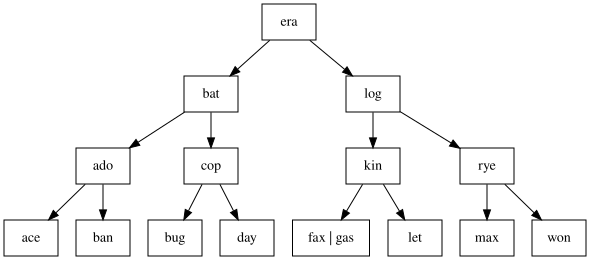

in-order traversal matches sorted input: True


In [50]:
btree = BTree(order=3)
for s in strings:
    btree.insert(s)

print("Final B Tree after all 16 insertions:")
display(visualize_btree(btree))

# sanity check: an in-order traversal must give every key in sorted order
print("in-order traversal matches sorted input:", btree.inorder() == sorted(strings))

## Task 8: Compare Internal Node Structure

In [51]:
print(f"B+ Tree: {bplus.internal_node_count()} internal nodes, {bplus.leaf_count()} leaf nodes, "
      f"{bplus.internal_node_count() + bplus.leaf_count()} nodes total")
print(f"B  Tree: {btree.internal_node_count()} internal nodes, {btree.leaf_count()} leaf nodes, "
      f"{btree.internal_node_count() + btree.leaf_count()} nodes total")

B+ Tree: 7 internal nodes, 11 leaf nodes, 18 nodes total


B  Tree: 7 internal nodes, 8 leaf nodes, 15 nodes total


**Which tree has fewer internal nodes, and why?**

With these 16 keys the two trees happened to land on the same number of internal nodes (7 each), but the B tree needed clearly fewer nodes overall (15 vs 18) because it only needed 8 leaves against the B+ tree's 11. The reason is where the keys live. In the B tree, 8 of the 16 keys sit inside internal nodes, so only 8 keys are left over to be stored in leaves. In the B+ tree, every single one of the 16 keys must live in a leaf, and the internal nodes hold duplicated copies acting as signposts. So the B+ tree always needs at least as many leaves as the B tree, and in general at least as many internal nodes to point at them. The B tree comes out equal or ahead on node count, and the gap grows with more data.

**So why do large-scale databases still prefer B+ trees?** Two reasons:

1. **Fan-out.** In a real database, a key in a B tree internal node drags its record data (or a record pointer) along with it, so fewer keys fit in one disk page. B+ tree internal nodes hold only keys and child pointers, so one page can hold far more separators. Bigger fan-out means a shallower tree, and every level saved is one less disk read per lookup.
2. **Range scans.** The B+ tree leaf chain means a range query is one walk down the tree followed by a sequential scan along linked leaves, which is exactly what disks and page caches are good at. In a B tree, collecting a range means jumping up and down between levels of the tree.

The trade-off the other way: a B tree can terminate a point lookup early if the key happens to sit in an internal node, while a B+ tree always walks to a leaf. For disk-based systems the consistent height and the cheap range scans win, which is why PostgreSQL, MySQL and friends all use B+ style indexes.

## Task 9: Range Query in a B+ Tree

Pseudocode:

```
RANGE-QUERY(T, low, high):
    result = empty list
    leaf = FIND-LEAF(T, low)            # normal walk down from the root, O(log n)
    while leaf is not NIL:
        for each key k in leaf.keys:    # keys inside a leaf are sorted
            if low <= k <= high:
                append k to result
            else if k > high:
                return result           # everything further right is bigger, stop
        leaf = leaf.next                # follow the leaf chain sideways
    return result
```

**How the leaf-level pointers help.** Without the leaf chain, collecting a range would mean a full tree traversal, going back up to parents and down into sibling subtrees for every leaf visited. With the chain, we pay for exactly one root-to-leaf walk to find where the range starts, and after that every additional result key is reached by following a single `next` pointer. The cost is O(log n + k) where k is the number of keys returned, and the leaf visits are sequential, which is exactly the access pattern disks and caches like. This is the structural reason `BETWEEN` queries on database indexes are cheap. The B tree from Task 7 cannot do this, because its keys are scattered across every level and its leaves are not linked.

In [52]:
# the range from the task sheet
print('range_query("cop", "max") =', bplus.range_query("cop", "max"))

# a range that starts before every key in the tree
print('range_query("aaa", "bzz") =', bplus.range_query("aaa", "bzz"))

# a range past the end of the data, should be empty
print('range_query("xxx", "zzz") =', bplus.range_query("xxx", "zzz"))

range_query("cop", "max") = ['cop', 'day', 'era', 'fax', 'gas', 'kin', 'let', 'log', 'max']
range_query("aaa", "bzz") = ['ace', 'ado', 'ban', 'bat', 'bug']
range_query("xxx", "zzz") = []


***

All nine tasks are complete: the reflection is in Task 1, the balance field is maintained through inserts and deletes with `is_balanced` on top, the common ancestor search verifies both nodes exist before walking down, all four rotations run against six scenarios including internal nodes and fully populated subtrees, the RB tree shows a verified figure after every one of the 15 operations, the B+ tree shows its structure after every third insertion with the leaf chain drawn, the B tree final state is shown, the node counts are compared, and the range query runs on the Task 6 tree.

***